# Super market sales project

<m>

## 1. Data wrangling and preparation

<m>

### 1.1 Import and read data

<br>

In [88]:
import pandas as pd
import numpy as np
import janitor as janitor
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from scipy import stats
import statsmodels.api as sm
from statsmodels.api import OLS
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
import psycopg2
import mysql.connector
import re
import ast
import openpyxl
import pyarrow
from fuzzywuzzy import fuzz,process
import geopandas as gpd
import warnings as warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
%matplotlib inline

In [89]:
df=pd.read_csv("supermarket_sales - Sheet1.csv")

In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


<br>

### 1.2 Exploratory data analysis

<br>

In [4]:
df.shape

(1000, 17)

In [5]:
report=sv.analyze(df)
report.show_html('profiling report.html')

In [6]:
report=ydp.ProfileReport(df)
report.to_file("data_profiling.html")

In [7]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [9]:
df.dtypes

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [10]:
df.index

RangeIndex(start=0, stop=1000, step=1)

In [11]:
print(df.duplicated().sum())

0


In [12]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

<br>

### 1.3 Data preperation

<br>

In [13]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [14]:
df=df[[ #'Branch'
       'Invoice ID','City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 
       #'gross margin percentage', 
       'gross income','Rating']].copy()

<m>

### 1.3.1 Dealing with outliers

##### Z-score - IQR

<m>

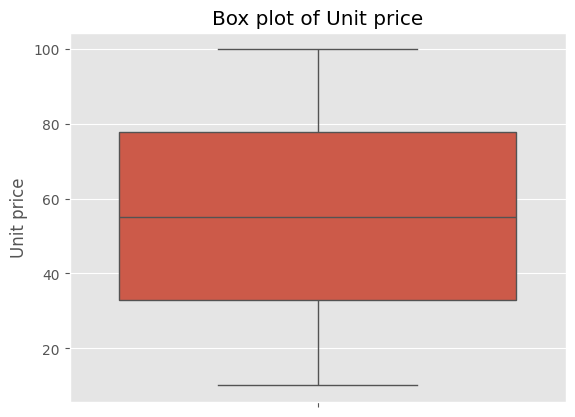

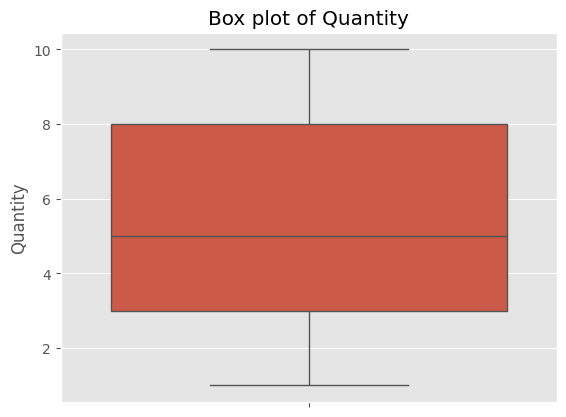

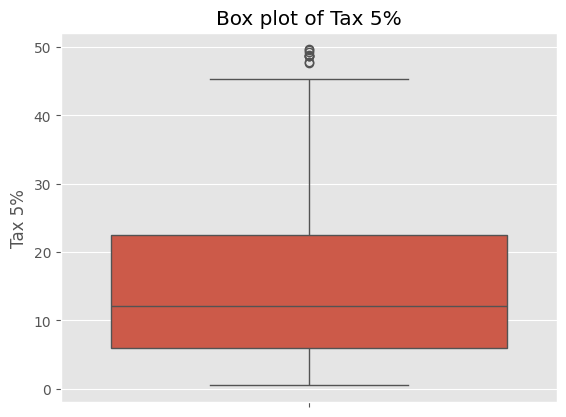

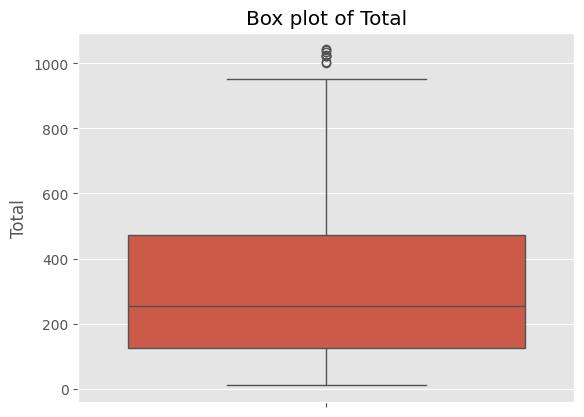

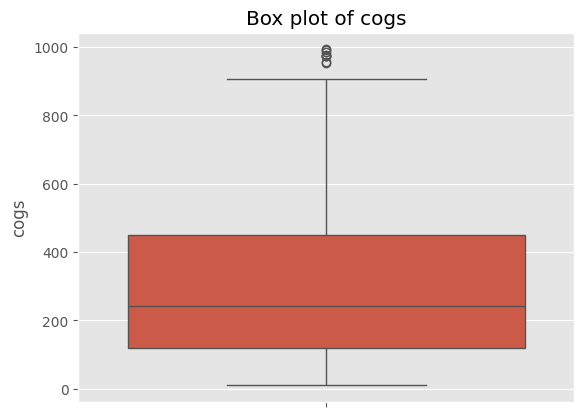

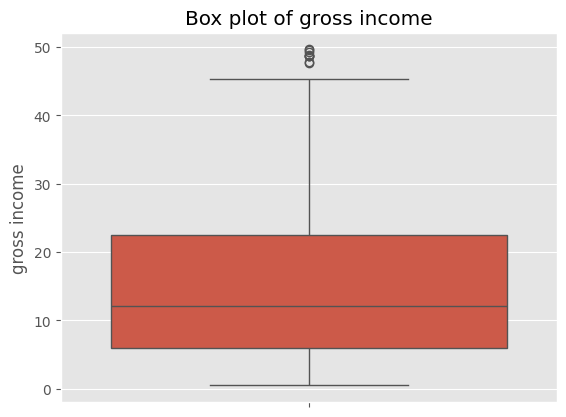

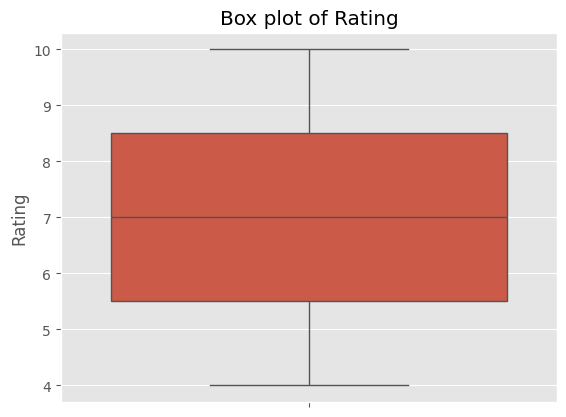

In [15]:
for column in ['Unit price', 'Quantity', 'Tax 5%', 'Total','cogs', 'gross income', 'Rating']:
    sns.boxplot(df[column])
    plt.title(f'Box plot of {column}')
    plt.show()

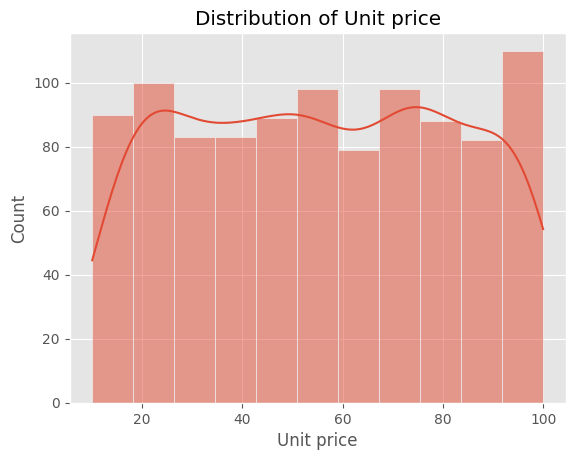

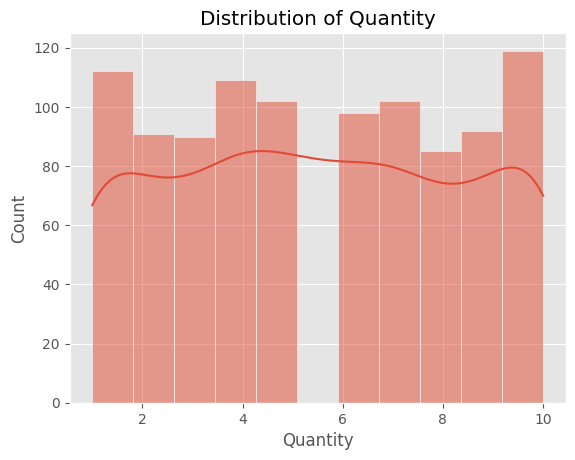

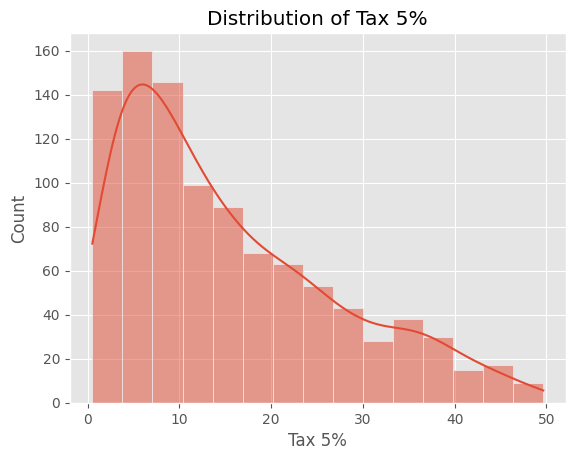

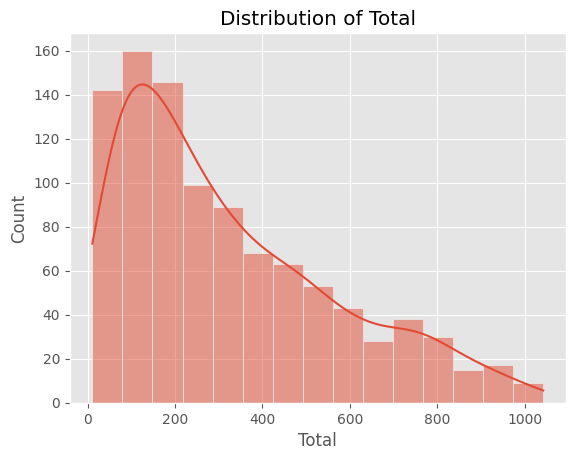

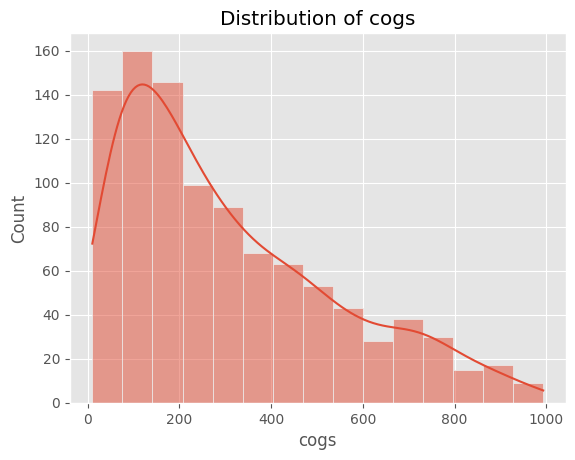

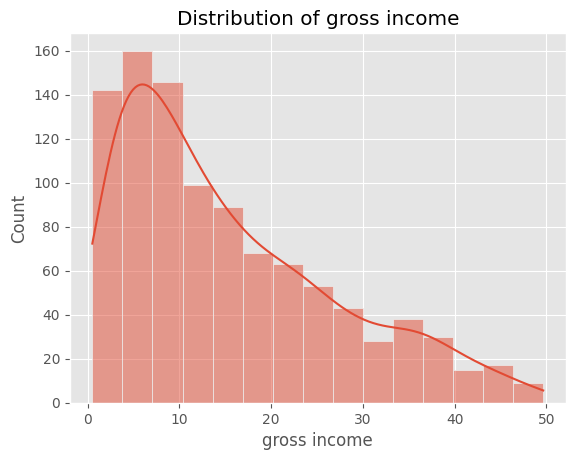

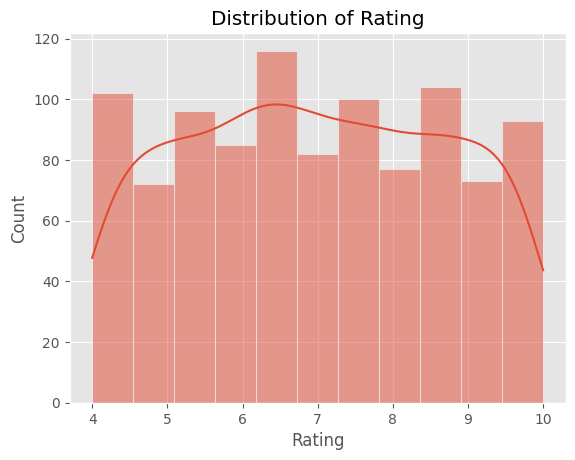

In [16]:
for column in ['Unit price', 'Quantity', 'Tax 5%', 'Total','cogs', 'gross income', 'Rating']:
    sns.histplot(df[column],kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

In [17]:
df[['Unit price', 'Quantity', 'Tax 5%', 'Total','cogs', 'gross income', 'Rating']].skew()

Unit price      0.007077
Quantity        0.012941
Tax 5%          0.892570
Total           0.892570
cogs            0.892570
gross income    0.892570
Rating          0.009010
dtype: float64

<M>

##### IQR

In [18]:
def detect_outliers_iqr_values(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return upper_bond,lower_bond

In [19]:
def iqr_outliers_values_sample(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return df[(df[column]>upper_bond) | (df[column]<lower_bond)].head()

In [20]:
def iqr_outliers_values_population(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return df[(df[column]>upper_bond) | (df[column]<lower_bond)].head()

<m>

##### IQR for Tax 5%, Total, cogs, gross income with skewness : 0.892

<m>

In [21]:
upper_bond,lower_bond=detect_outliers_iqr_values(df,'Tax 5%')
print(f'Upper bond = {upper_bond}\nLower bond = {lower_bond}')

Upper bond = 47.2258125
Lower bond = -18.855687500000002


In [22]:
iqr_outliers_values_sample(df,'Tax 5%')

,Invoice ID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross income,Rating
166,234-65-2137,Naypyitaw,Normal,Male,Home and lifestyle,95.58,10,47.790,1003.590,1/16/2019,13:32,Cash,955.8,47.790,4.8
167,687-47-8271,Yangon,Normal,Male,Fashion accessories,98.98,10,49.490,1039.290,2/8/2019,16:20,Credit card,989.8,49.490,8.7
350,860-79-0874,Naypyitaw,Member,Female,Fashion accessories,99.30,10,49.650,1042.650,2/15/2019,14:53,Credit card,993.0,49.650,6.6
357,554-42-2417,Naypyitaw,Normal,Female,Sports and travel,95.44,10,47.720,1002.120,1/9/2019,13:45,Cash,954.4,47.720,5.2
422,271-88-8734,Naypyitaw,Member,Female,Fashion accessories,97.21,10,48.605,1020.705,2/8/2019,13:00,Credit card,972.1,48.605,8.7


In [23]:
tax_pop=iqr_outliers_values_population(df,'Tax 5%')

In [24]:
tax_pop.sort_values(by='Tax 5%',ascending=False).head()

,Invoice ID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross income,Rating
350,860-79-0874,Naypyitaw,Member,Female,Fashion accessories,99.30,10,49.650,1042.650,2/15/2019,14:53,Credit card,993.0,49.650,6.6
167,687-47-8271,Yangon,Normal,Male,Fashion accessories,98.98,10,49.490,1039.290,2/8/2019,16:20,Credit card,989.8,49.490,8.7
422,271-88-8734,Naypyitaw,Member,Female,Fashion accessories,97.21,10,48.605,1020.705,2/8/2019,13:00,Credit card,972.1,48.605,8.7
166,234-65-2137,Naypyitaw,Normal,Male,Home and lifestyle,95.58,10,47.790,1003.590,1/16/2019,13:32,Cash,955.8,47.790,4.8
357,554-42-2417,Naypyitaw,Normal,Female,Sports and travel,95.44,10,47.720,1002.120,1/9/2019,13:45,Cash,954.4,47.720,5.2


##### There is no outliers in tax 5% because the highest value is 49.65 and the upper bond is 47.22 wich is resonable

##### There is no outliers in any of these columns because they have the same skewness and ranges

<m>

##### Z-score

In [25]:
def detect_outliers_z_score_values(df,column):
    upper_limit=df[column].mean()+3*df[column].std()
    lower_limit=df[column].mean()-3*df[column].std()
    return upper_limit,lower_limit

In [26]:
def detect_outliers_z_score_sample(df,column):
    upper_limit=df[column].mean()+3*df[column].std()
    lower_limit=df[column].mean()-3*df[column].std()
    return df[(df[column]>upper_limit) | (df[column]<lower_limit)].head()

In [27]:
def detect_outliers_z_score_population(df,column):
    upper_limit=df[column].mean()+3*df[column].std()
    lower_limit=df[column].mean()-3*df[column].std()
    return df[(df[column]>upper_limit) | (df[column]<lower_limit)]

<m>

##### Z-score for quantity with skewness : 0.012

<m>

In [28]:
upper_limit,lower_limit=detect_outliers_z_score_values(df,'Quantity')
print(f'Upper bond = {upper_limit}\nLower bond = {lower_limit}')

Upper bond = 14.280291786367089
Lower bond = -3.2602917863670893


In [29]:
detect_outliers_z_score_sample(df,'Quantity')

,Invoice ID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross income,Rating


##### There is no outliers in quantity

<M>

##### Z-score for rating with skewness : 0.009

<m>

In [30]:
upper_limit,lower_limit=detect_outliers_z_score_values(df,'Rating')
print(f'Upper bond = {upper_limit}\nLower bond = {lower_limit}')

Upper bond = 12.128440883137365
Lower bond = 1.816959116862635


In [31]:
detect_outliers_z_score_sample(df,'Rating')

,Invoice ID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross income,Rating


##### There is no outliers in rating

<m>

##### Z-score for unit price with skewness : 0.007

<m>

In [32]:
upper_limit,lower_limit=detect_outliers_z_score_values(df,'Unit price')
print(f'Upper bond = {upper_limit}\nLower bond = {lower_limit}')

Upper bond = 135.15601504375934
Lower bond = -23.811755043759327


In [33]:
detect_outliers_z_score_sample(df,'Unit price')

,Invoice ID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross income,Rating


##### There is no outliers in unit price

<m>

### 1.3.2 Formatting and adding columns

<m>

##### date format

In [34]:
df["Date"]=pd.to_datetime(df["Date"])

In [35]:
try:
    pd.to_datetime(df["Date"])
    print("Valid datetime format")
except ValueError:
    print("Invalid datetime format")

Valid datetime format


In [36]:
df["Date"]=df["Date"].dt.date

##### rating status

In [37]:
df["rating_status"]="undefined"

In [38]:
for index,row in df.iterrows():
    if row["Rating"]<=6:
        df.loc[index,"rating_status"]="low rating"
    elif row["Rating"]<=8:
        df.loc[index,"rating_status"]="medium rating"
    elif row["Rating"]>8:
        df.loc[index,"rating_status"]="high rating"    

##### order status

In [39]:
df["order_status"]="undifiend"

In [40]:
for index,row in df.iterrows():
    if row["Quantity"]<=3:
        df.loc[index,"order_status"]="small order"
    elif row["Quantity"]<=6:
        df.loc[index,"order_status"]="medium order"    
    elif row["Quantity"]>6:
        df.loc[index,"order_status"]="large order"    

<br>

### 1.4 Features understanding


<br>

### (Univariate analysis)

<br>

Distribution of features

<m>

In [41]:
df.columns

Index(['Invoice ID', 'City', 'Customer type', 'Gender', 'Product line',
       'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment',
       'cogs', 'gross income', 'Rating', 'rating_status', 'order_status'],
      dtype='str')

Categorical Features

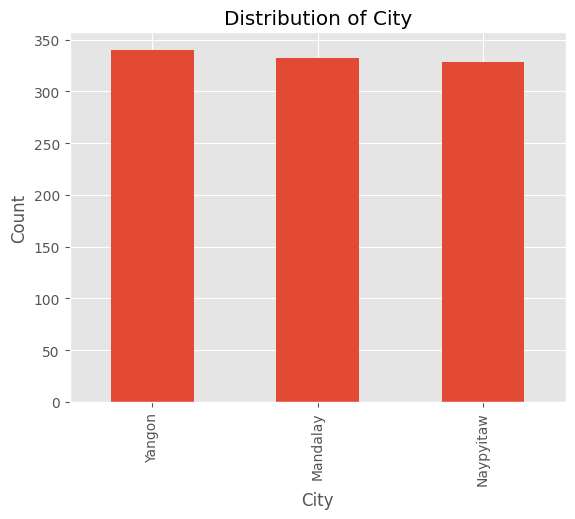

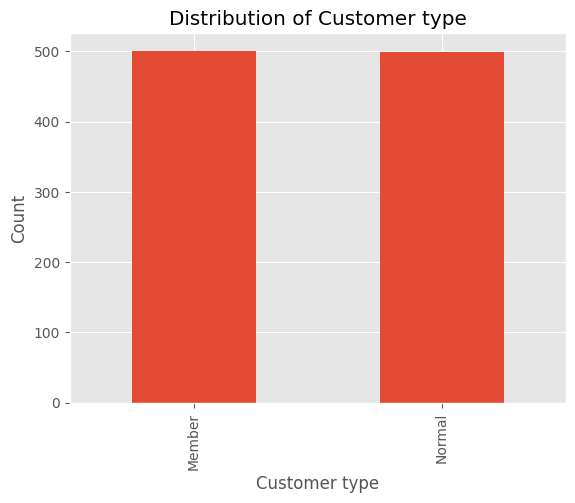

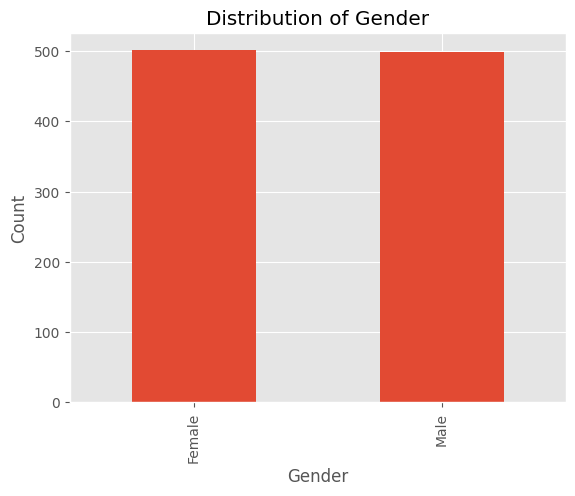

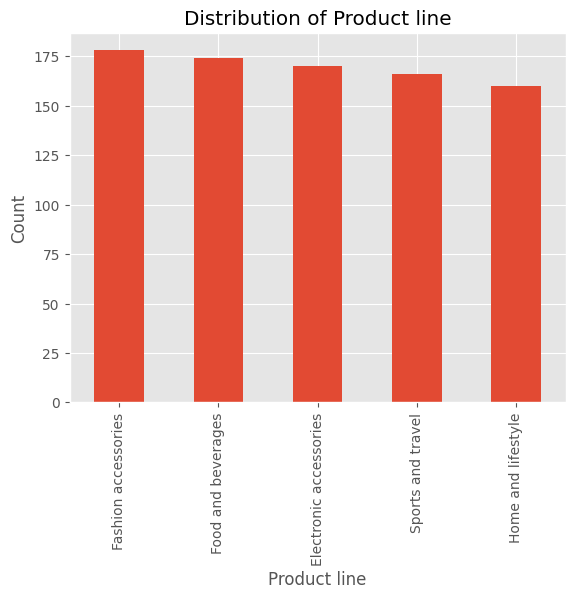

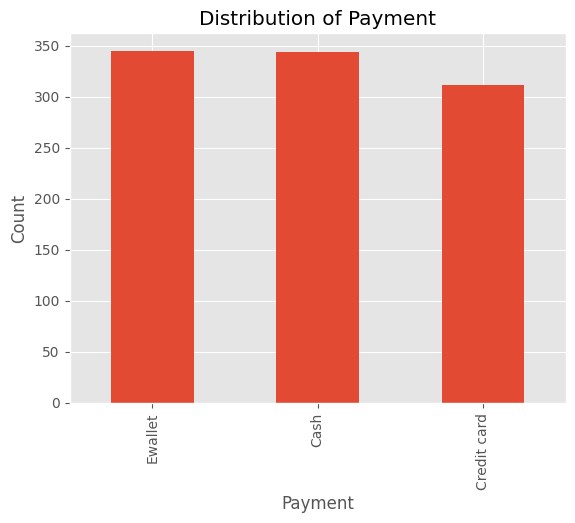

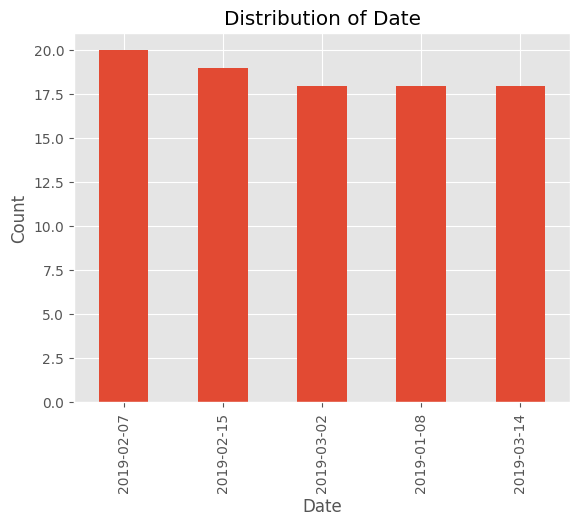

In [42]:
for column in ['City','Customer type','Gender','Product line','Payment','Date']:
    ax=df[column].value_counts().head().plot(kind='bar',title=f'Distribution of {column}')
    ax.set_xlabel(f'{column}')
    ax.set_ylabel("Count")
    plt.show()

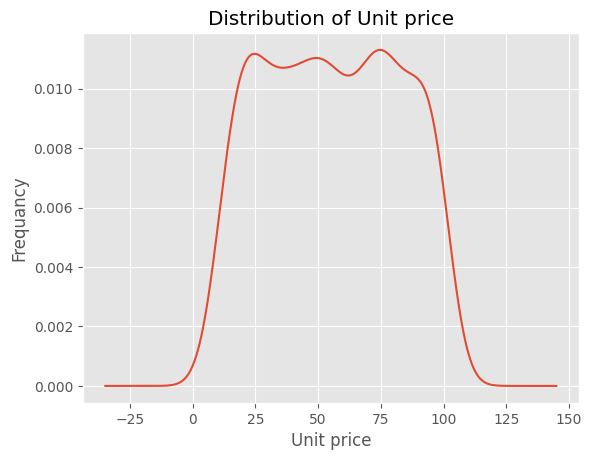

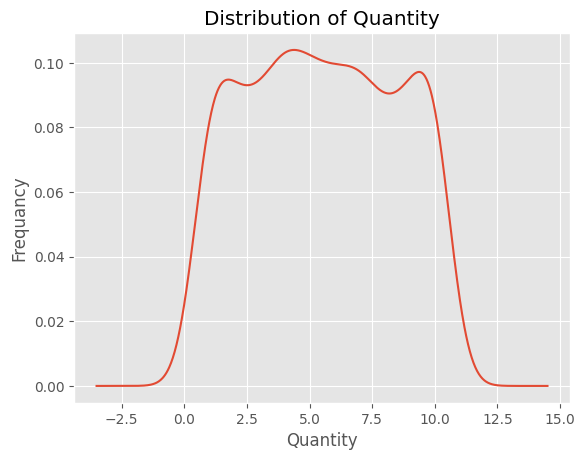

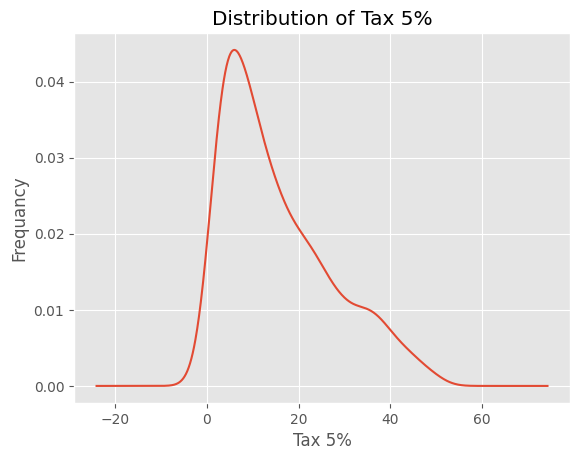

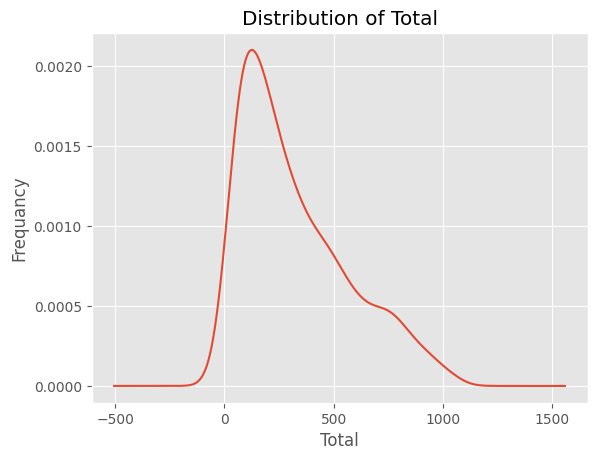

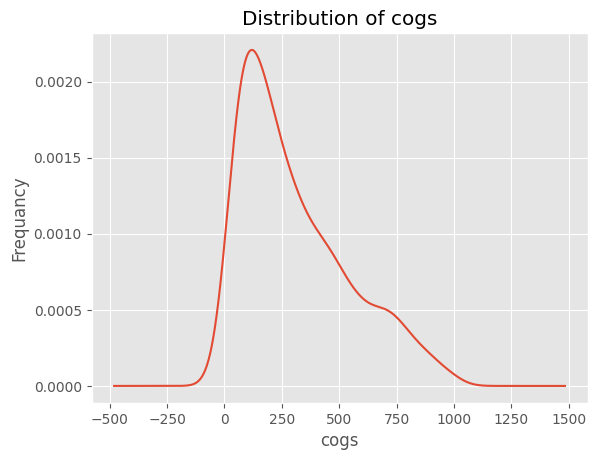

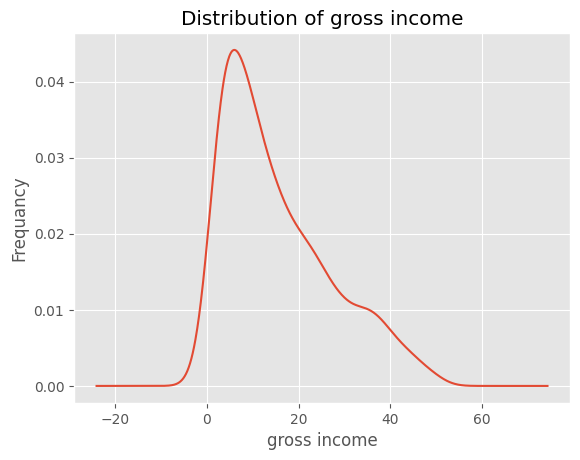

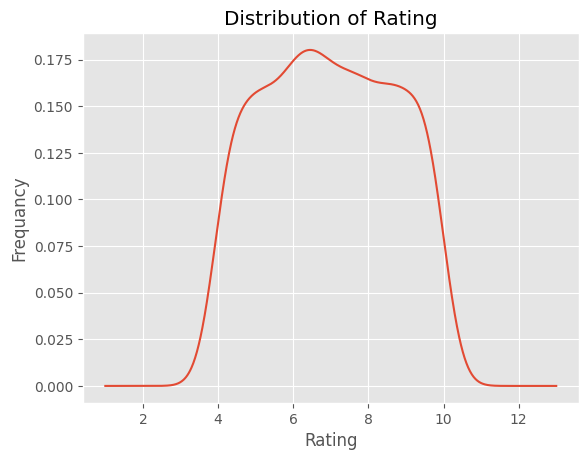

In [43]:
for column in ['Unit price', 'Quantity', 'Tax 5%', 'Total','cogs', 'gross income', 'Rating']:
    ax=df[column].plot(kind='kde',title=f"Distribution of {column}")
    ax.set_xlabel(f"{column}")
    ax.set_ylabel("Frequancy")
    plt.show()

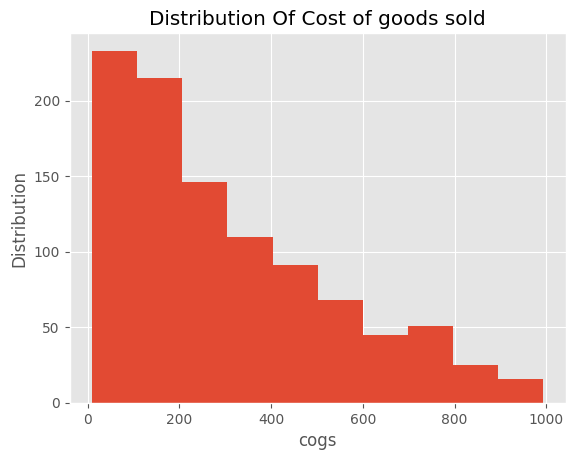

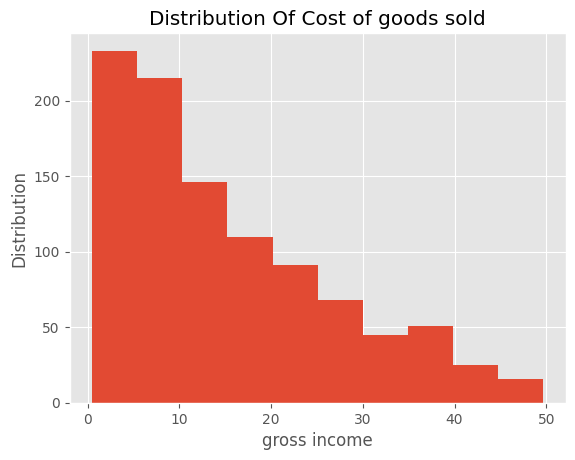

In [44]:
for column in ['cogs','gross income']:
    ax=df[column].plot(kind='hist',title="Distribution Of Cost of goods sold")
    ax.set_xlabel(f"{column}")
    ax.set_ylabel("Distribution")
    plt.show()

<br>

### 1.5 Import to sql-server

<m>

In [ ]:
df_sql = df.copy()
df_sql.columns = [c.replace(" ", "_").replace("-", "_") for c in df_sql.columns]

In [ ]:
server = r'DESKTOP-KHP38V4'
database = 'Supermarket'
driver = 'ODBC Driver 17 for SQL Server'
conn_str = (
    f"mssql+pyodbc://@{server}/{database}"
    f"?driver={driver.replace(' ', '+')}"
    "&trusted_connection=yes")
engine = create_engine(conn_str)
df_sql.to_sql('Supermarket_table', engine, if_exists='replace', index=False)

<m>

## 2. Analyzing data

### 2.1 Heatmap

<bb>

In [45]:
df_numeric=df.select_dtypes(include="number")
cor1=df_numeric.corr()
cor1

,Unit price,Quantity,Tax 5%,Total,cogs,gross income,Rating
Unit price,1.000000,0.010778,0.633962,0.633962,0.633962,0.633962,-0.008778
Quantity,0.010778,1.000000,0.705510,0.705510,0.705510,0.705510,-0.015815
Tax 5%,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
Total,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
gross income,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
Rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,-0.036442,1.000000


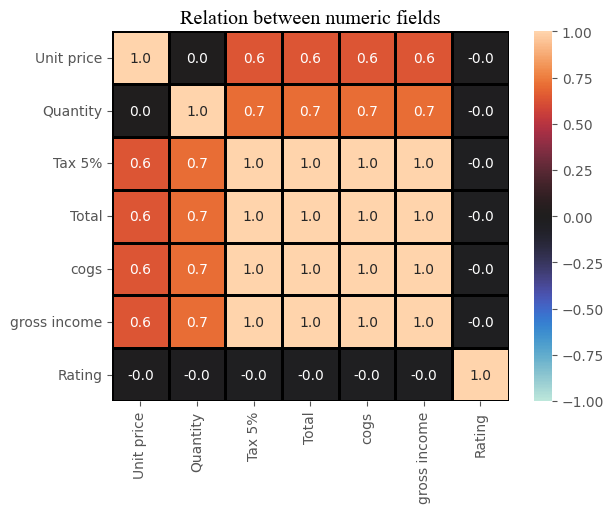

In [46]:
sns.heatmap(cor1,annot=True,vmin=-1,vmax=1,center=0,fmt='.1f',linewidth=1,linecolor="k")
plt.title("Relation between numeric fields",fontfamily="times new roman")
plt.show()

<m>

### 2.2 City with the most demand

<b>

In [47]:
city_qty=df.groupby("City").Quantity.sum().sort_values(ascending=False)
city_qty

City
Yangon       1859
Naypyitaw    1831
Mandalay     1820
Name: Quantity, dtype: int64

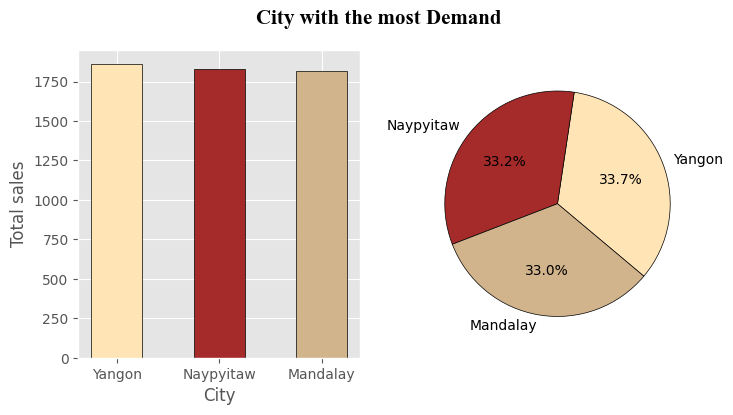

In [48]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(8,4))
color=["moccasin","brown","tan"]
ex=[0,0,0.1]
axis[0].bar(city_qty.index,city_qty.values,color=color,edgecolor="k",width=0.5)
axis[0].set_xlabel("City")
axis[0].set_ylabel("Total sales")
axis[1].pie(city_qty.values,labels=city_qty.index,autopct="%1.1f%%",colors=color,startangle=-40,wedgeprops={'edgecolor': 'black'})
fig.suptitle("City with the most Demand",fontname="Times New Roman", size=15,fontweight="bold")
plt.show()

<b>

### 2.3 City with the highst rating

<b>

In [49]:
crating=df.groupby("City").Rating.sum().sort_values(ascending=False)
crating

City
Yangon       2389.2
Naypyitaw    2319.9
Mandalay     2263.6
Name: Rating, dtype: float64

In [50]:
ccount=df["City"].value_counts()
ccount

City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

In [51]:
cavgrating=crating/ccount
cavgrating

City
Mandalay     6.818072
Naypyitaw    7.072866
Yangon       7.027059
dtype: float64

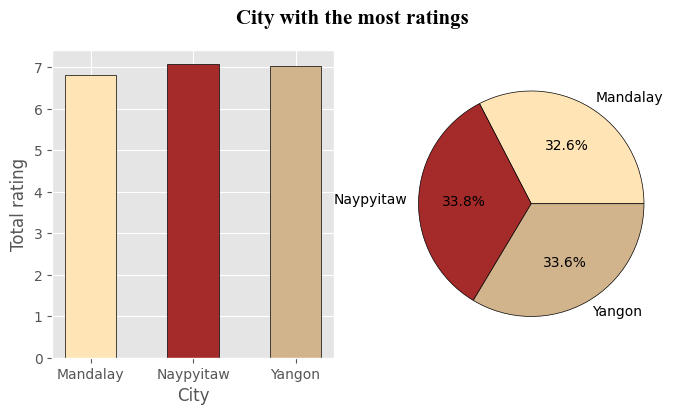

In [52]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(8,4))
color=["moccasin","brown","tan"]
axis[0].bar(cavgrating.index,cavgrating.values,width=0.5,edgecolor="k",color=color)
axis[0].set_xlabel("City")
axis[0].set_ylabel("Total rating")
axis[1].pie(cavgrating.values,labels=cavgrating.index,autopct='%1.1f%%',colors=color,wedgeprops={'edgecolor': 'black'})
fig.suptitle("City with the most ratings",fontfamily="times new roman",fontsize=15,fontweight="bold")
plt.show()

<m>

### 2.4 City with the most sales

<m>

In [53]:
citysales=df.groupby("City").Total.sum().sort_values(ascending=False)
citysales

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Total, dtype: float64

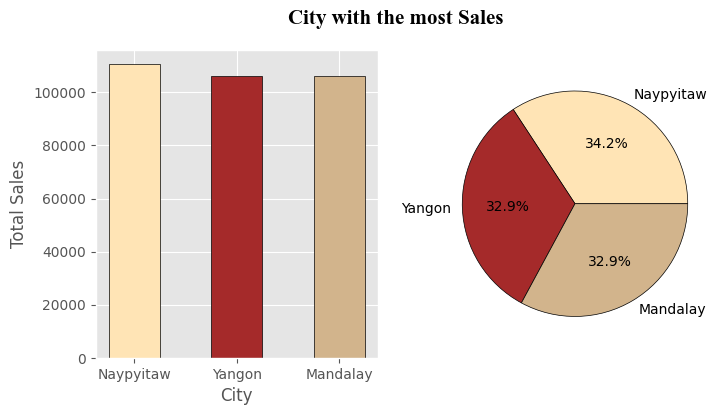

In [54]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(8,4))
color=["moccasin","brown","tan"]
axis[0].bar(citysales.index,citysales.values,width=0.5,edgecolor="k",color=color)
axis[0].set_xlabel("City")
axis[0].set_ylabel("Total Sales")
axis[1].pie(citysales.values,labels=citysales.index,autopct='%1.1f%%',colors=color,wedgeprops={'edgecolor': 'black'})
fig.suptitle("City with the most Sales",fontfamily="times new roman",fontsize=15,fontweight="bold")
plt.show()

<d>

### 2.5 Important gender 

<m>

In [55]:
g_inc=df.groupby("Gender")['gross income'].sum().sort_values(ascending=False)
g_rev=df.groupby("Gender").Total.sum().sort_values(ascending=False)
g_qty=df.groupby("Gender").Quantity.sum().sort_values(ascending=False)
g_inc

Gender
Female    7994.425
Male      7384.944
Name: gross income, dtype: float64

In [56]:
g_rev

Gender
Female    167882.925
Male      155083.824
Name: Total, dtype: float64

In [57]:
g_qty

Gender
Female    2869
Male      2641
Name: Quantity, dtype: int64

In [58]:
summary_df=pd.concat([g_rev,g_inc,g_qty],axis=1).reset_index().rename(columns={'index':'Gender'})
melted_df=summary_df.melt(id_vars="Gender",value_vars=['Total','gross income','Quantity'],var_name="Metric",value_name='Value')

In [59]:
summary_df

,Gender,Total,gross income,Quantity
0,Female,167882.925,7994.425,2869
1,Male,155083.824,7384.944,2641


In [60]:
melted_df

,Gender,Metric,Value
0,Female,Total,167882.925
1,Male,Total,155083.824
2,Female,gross income,7994.425
3,Male,gross income,7384.944
4,Female,Quantity,2869.000
5,Male,Quantity,2641.000


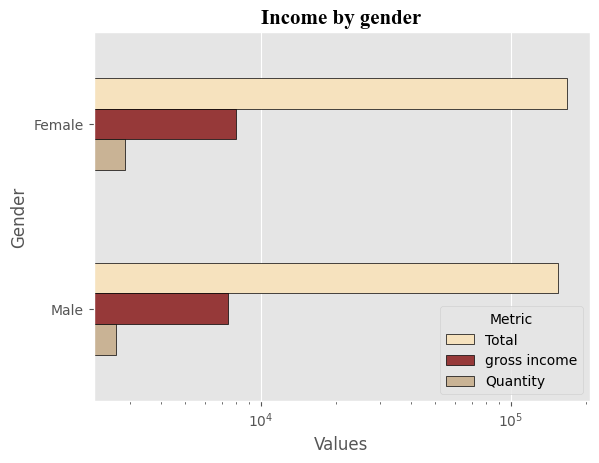

In [61]:
sns.barplot(x="Value",y="Gender",hue="Metric",data=melted_df,edgecolor="k", palette=["moccasin", "brown","tan"],width=0.5)
plt.xscale('log')
plt.title("Income by gender",fontfamily="times new roman",fontsize=15,fontweight="bold")
plt.xlabel("Values")
plt.ylabel("Gender")
plt.show()

<m>

### 2.6 Important customer type

<m>

In [62]:
df["Customer type"].unique()	

<ArrowStringArray>
['Member', 'Normal']
Length: 2, dtype: str

In [63]:
ct_income=df.groupby("Customer type")['gross income'].sum().sort_values(ascending=False)
ct_rev=df.groupby("Customer type").Total.sum().sort_values(ascending=False)
ct_income

Customer type
Member    7820.164
Normal    7559.205
Name: gross income, dtype: float64

In [64]:
ct_rev

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64

In [65]:
summary_df1=pd.concat([ct_rev,ct_income],axis=1).reset_index().rename(columns={'index':'Customer type'})
melted_df1=summary_df1.melt(id_vars='Customer type',value_vars=['Total','gross income'],var_name='Metric',value_name='Value')

In [66]:
summary_df1

,Customer type,Total,gross income
0,Member,164223.444,7820.164
1,Normal,158743.305,7559.205


In [67]:
melted_df1

,Customer type,Metric,Value
0,Member,Total,164223.444
1,Normal,Total,158743.305
2,Member,gross income,7820.164
3,Normal,gross income,7559.205


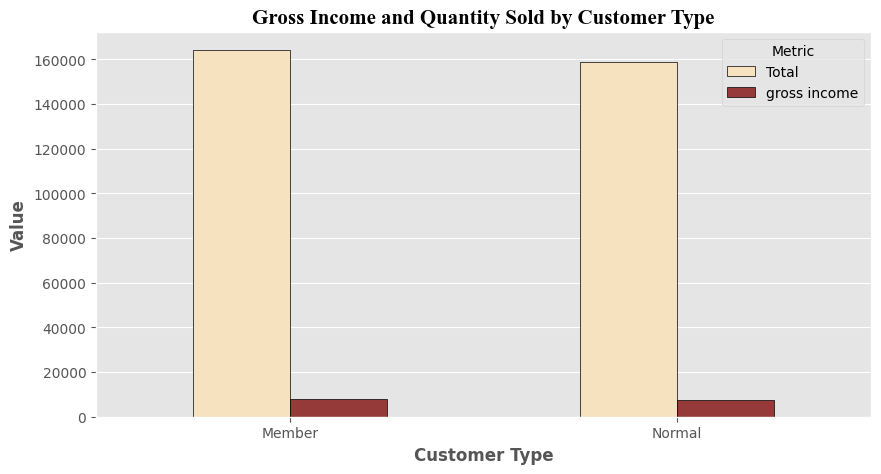

In [68]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Customer type', y='Value', hue='Metric', data=melted_df1,width=0.5,edgecolor="k",palette=["moccasin", "brown"])
plt.xlabel('Customer Type', fontweight='bold')
plt.ylabel('Value', fontweight='bold')
plt.title('Gross Income and Quantity Sold by Customer Type', fontweight='bold',fontfamily="times new roman",fontsize=15)
plt.show()

<m>

### 2.7 Product line analysis

<m>

In [69]:
df["Product line"].unique()

<ArrowStringArray>
[     'Health and beauty', 'Electronic accessories',     'Home and lifestyle',
      'Sports and travel',     'Food and beverages',    'Fashion accessories']
Length: 6, dtype: str

In [70]:
pl_income=df.groupby("Product line")['gross income'].sum().sort_values(ascending=False)
pl_income

Product line
Food and beverages        2673.5640
Sports and travel         2624.8965
Electronic accessories    2587.5015
Fashion accessories       2585.9950
Home and lifestyle        2564.8530
Health and beauty         2342.5590
Name: gross income, dtype: float64

In [71]:
pl_revenue=df.groupby("Product line").Total.sum().sort_values(ascending=False)
pl_revenue

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

In [72]:
pl_qty=df.groupby("Product line").Quantity.sum().sort_values(ascending=False)
pl_qty

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64

In [73]:
summary_df3=pd.concat([pl_revenue,pl_income,pl_qty],axis=1).reset_index().rename(columns={'index':'product_line'})

In [74]:
melted_df3=summary_df3.melt(id_vars="Product line",value_vars=['Total','gross income','Quantity'],var_name="Metric",value_name='Value')

In [75]:
summary_df3

,Product line,Total,gross income,Quantity
0,Food and beverages,56144.8440,2673.5640,952
1,Sports and travel,55122.8265,2624.8965,920
2,Electronic accessories,54337.5315,2587.5015,971
3,Fashion accessories,54305.8950,2585.9950,902
4,Home and lifestyle,53861.9130,2564.8530,911
5,Health and beauty,49193.7390,2342.5590,854


In [76]:
melted_df3

,Product line,Metric,Value
0,Food and beverages,Total,56144.8440
1,Sports and travel,Total,55122.8265
2,Electronic accessories,Total,54337.5315
3,Fashion accessories,Total,54305.8950
4,Home and lifestyle,Total,53861.9130
5,Health and beauty,Total,49193.7390
6,Food and beverages,gross income,2673.5640
7,Sports and travel,gross income,2624.8965
8,Electronic accessories,gross income,2587.5015
9,Fashion accessories,gross income,2585.9950


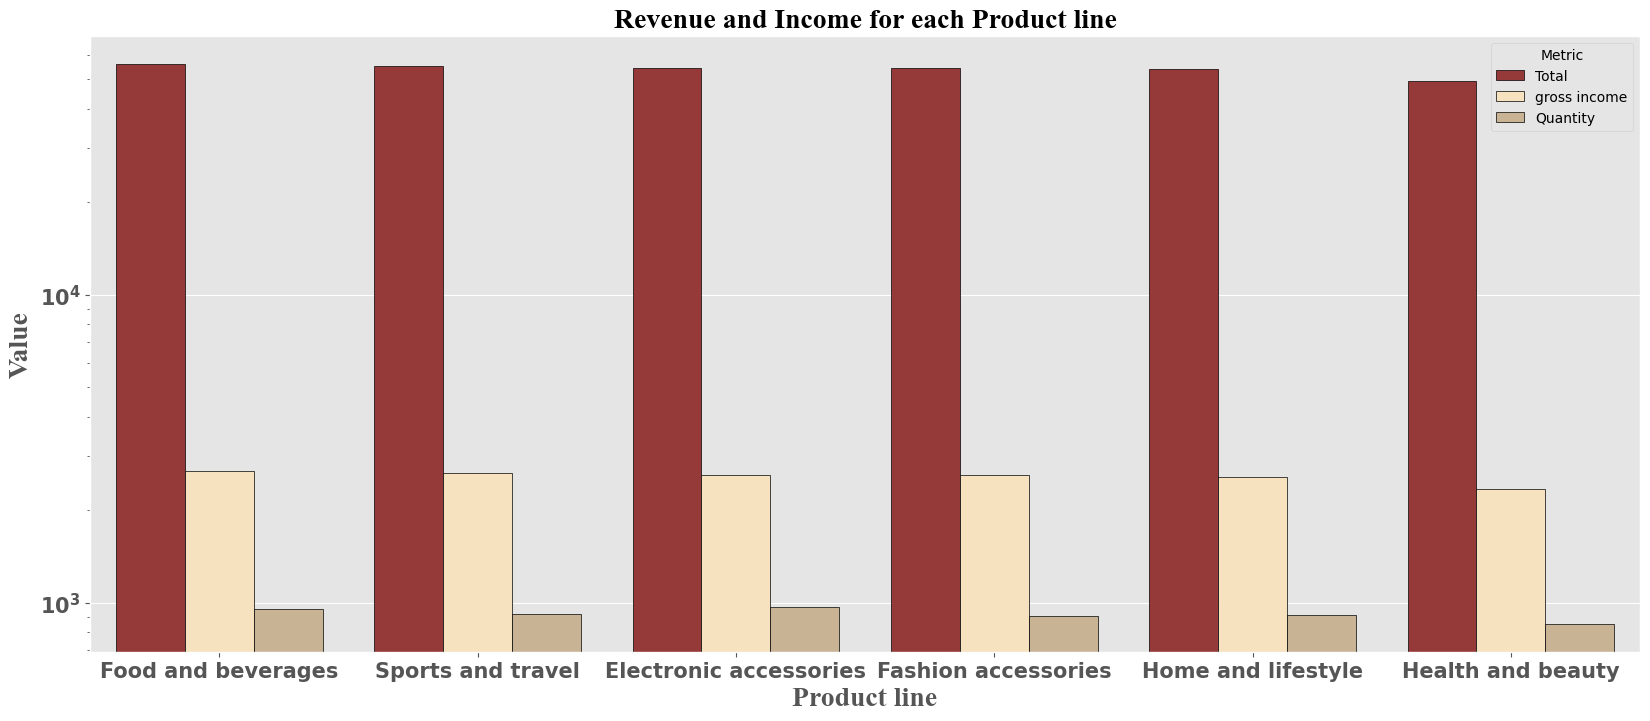

In [77]:
plt.figure(figsize=(20,8))
sns.barplot(x='Product line',y='Value',hue='Metric',data=melted_df3,palette=["brown","moccasin","Tan"],edgecolor="k")
plt.yscale('log')
plt.title("Revenue and Income for each Product line",fontfamily="times new roman",fontweight="bold",fontsize=20)
plt.xlabel("Product line",fontsize=20,fontweight='bold',fontfamily="times new roman")
plt.ylabel("Value",fontsize=20,fontweight='bold',fontfamily="times new roman")
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
plt.show()

<b>

### 2.8 Product line with the highest ratings

<m>

In [78]:
pl_rat=df.groupby("Product line").Rating.sum().sort_values(ascending=False)
pl_rat

Product line
Fashion accessories       1251.2
Food and beverages        1237.7
Electronic accessories    1177.2
Sports and travel         1148.1
Home and lifestyle        1094.0
Health and beauty         1064.5
Name: Rating, dtype: float64

In [79]:
pl_freq=df['Product line'].value_counts()
pl_freq

Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

In [80]:
pl_avg_rating=pl_rat/pl_freq
pl_avg_rating=pl_avg_rating.sort_values(ascending=True)
pl_avg_rating

Product line
Home and lifestyle        6.837500
Sports and travel         6.916265
Electronic accessories    6.924706
Health and beauty         7.003289
Fashion accessories       7.029213
Food and beverages        7.113218
dtype: float64

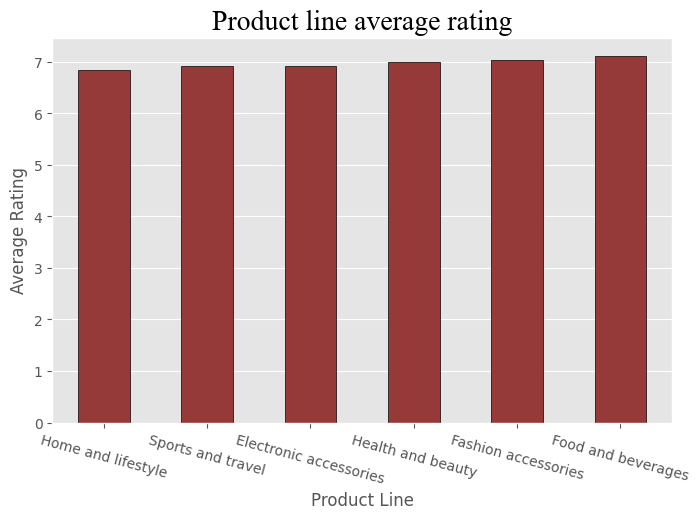

In [81]:
plt.figure(figsize=(8,5))
sns.barplot(x=pl_avg_rating.index,y=pl_avg_rating.values,width=0.5,palette=["brown"],edgecolor="k")
plt.title("Product line average rating",fontfamily="times new roman",size=20)
plt.xlabel("Product Line")
plt.ylabel("Average Rating")
plt.xticks(rotation=-15)
plt.show()

<m>

### 2.9 Relation between payment type and quantity

<m>

In [82]:
df.columns

Index(['Invoice ID', 'City', 'Customer type', 'Gender', 'Product line',
       'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment',
       'cogs', 'gross income', 'Rating', 'rating_status', 'order_status'],
      dtype='str')

In [83]:
pt_qty=df.groupby("Payment")['Quantity'].mean().sort_values(ascending=False)
pt_qty

Payment
Credit card    5.536977
Cash           5.511628
Ewallet        5.484058
Name: Quantity, dtype: float64

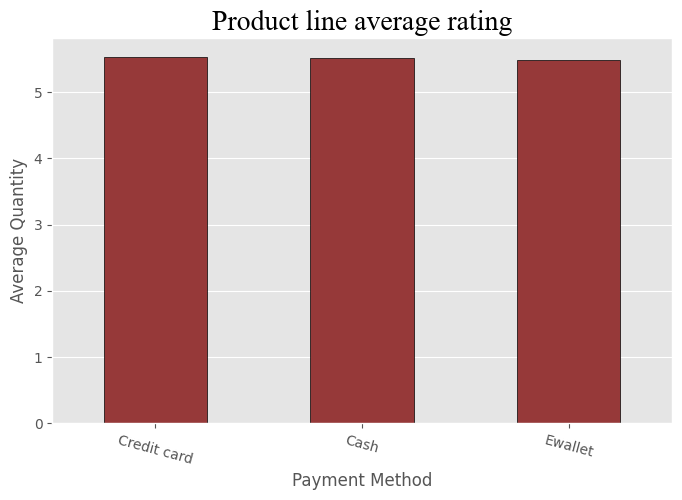

In [84]:
plt.figure(figsize=(8,5))
sns.barplot(x=pt_qty.index,y=pt_qty.values,width=0.5,palette=["brown"],edgecolor="k")
plt.title("Product line average rating",fontfamily="times new roman",size=20)
plt.xlabel("Payment Method")
plt.ylabel("Average Quantity")
plt.xticks(rotation=-15)
plt.show()

<m>

### 2.10 Sales periode analysis

<m>

In [85]:
income_by_date = df.groupby('Date')['gross income'].sum().reset_index()
income_by_date

,Date,gross income
0,2019-01-01,225.9610
1,2019-01-02,92.6430
2,2019-01-03,98.9585
3,2019-01-04,77.3185
4,2019-01-05,168.4135
...,...,...
84,2019-03-26,93.4530
85,2019-03-27,138.2295
86,2019-03-28,106.1620
87,2019-03-29,191.5830


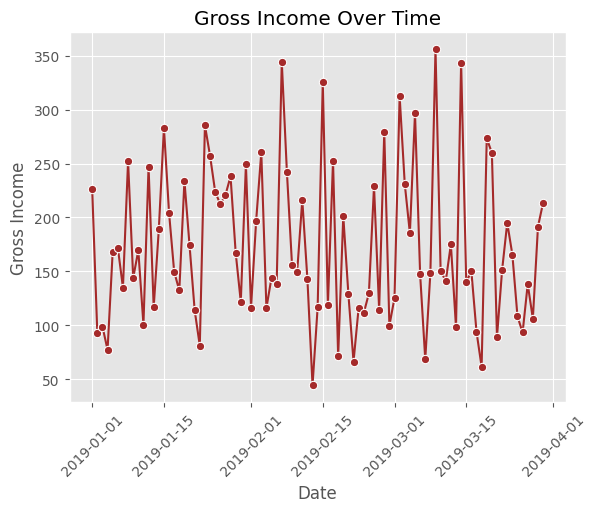

In [86]:
sns.lineplot(x=income_by_date['Date'], y=income_by_date['gross income'], marker='o', linestyle='-', color='brown')
plt.title('Gross Income Over Time')
plt.xlabel('Date')
plt.ylabel('Gross Income')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

<m>

### 2.11 Relation between price and rating

<m>

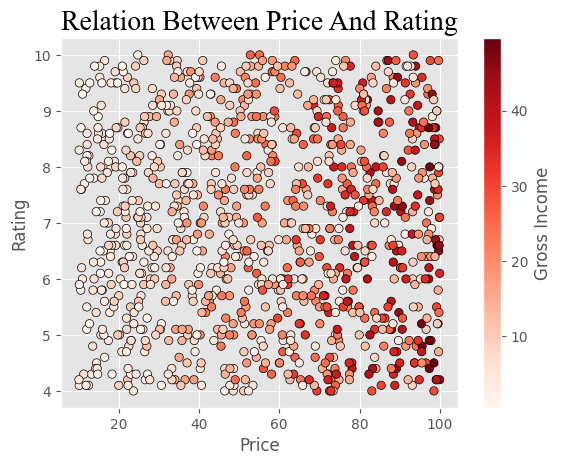

In [87]:
plt.scatter(df["Unit price"],df["Rating"],edgecolor="k",cmap='Reds',c=df['gross income'])
plt.colorbar(label='Gross Income')
plt.title("Relation Between Price And Rating",fontfamily='times new roman',size=20)
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()